In [6]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn  as nn
import torch.nn.functional as F
import torch.optim as optim
import torch


transform = transforms.ToTensor()  

train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=transform,   
    download=True
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=transform,   
    download=True
)



loader = {

    'train': DataLoader(
        train_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    ),

    'test': DataLoader(
        test_data,
        batch_size=100,
        shuffle=False,
        num_workers=1

    )
}

class CNN(nn.Module):
    
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(1,10,kernel_size=5)
        self.conv2 = nn.Conv2d(10,20,kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320,50)
        self.fc2 = nn.Linear(50,10)

    def forward(self,x):
        x = F.relu(F.max_pool2d(self.conv1(x),2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)),2))
        x = x.view(-1,320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training= self.training)
        x = self.fc2(x)

        return F.softmax(x)
    

    

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.Adam(model.parameters(),lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data,target)in enumerate(loader['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output,target)
        loss.backward()
        optimizer.step()
        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(loader["train"].dataset)} ({100.*batch_idx / len(loader["train"]):.0f}%)]\t{loss.item():.6f}')


def test():
    model.eval()

    test_loss = 0
    correct = 0
    
    with torch.no_grad():
        for data, target in loader['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim = 1,keepdim= True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(loader['test'].dataset)
    print(f'\nTest set: Average loss : {test_loss:.4f}, Accuracy {correct}/{len(loader["test"].dataset)}({100. * correct / len(loader["test"].dataset):.0f}%\n)')

In [7]:
for epoch in range(1, 11):
    train(epoch)
    test()

C:\Users\quaiu\AppData\Local\Temp\ipykernel_21644\1592228336.py:64: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train Epoch: 1 [0/60000 (0%)]	2.301653
Train Epoch: 1 [2000/60000 (3%)]	2.291440
Train Epoch: 1 [4000/60000 (7%)]	2.221029
Train Epoch: 1 [6000/60000 (10%)]	2.056879
Train Epoch: 1 [8000/60000 (13%)]	1.944777
Train Epoch: 1 [10000/60000 (17%)]	1.785379
Train Epoch: 1 [12000/60000 (20%)]	1.873597
Train Epoch: 1 [14000/60000 (23%)]	1.822278
Train Epoch: 1 [16000/60000 (27%)]	1.784394
Train Epoch: 1 [18000/60000 (30%)]	1.759768
Train Epoch: 1 [20000/60000 (33%)]	1.828473
Train Epoch: 1 [22000/60000 (37%)]	1.795781
Train Epoch: 1 [24000/60000 (40%)]	1.725278
Train Epoch: 1 [26000/60000 (43%)]	1.733676
Train Epoch: 1 [28000/60000 (47%)]	1.756058
Train Epoch: 1 [30000/60000 (50%)]	1.666155
Train Epoch: 1 [32000/60000 (53%)]	1.731702
Train Epoch: 1 [34000/60000 (57%)]	1.699860
Train Epoch: 1 [36000/60000 (60%)]	1.657928
Train Epoch: 1 [38000/60000 (63%)]	1.630835
Train Epoch: 1 [40000/60000 (67%)]	1.701156
Train Epoch: 1 [42000/60000 (70%)]	1.636115
Train Epoch: 1 [44000/60000 (73%)]	1.626979

prediction: 1


C:\Users\quaiu\AppData\Local\Temp\ipykernel_21644\1592228336.py:64: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


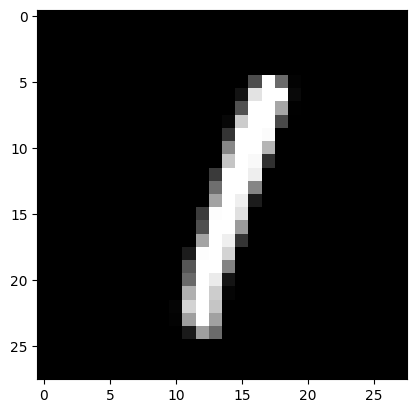

In [10]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[5]

data = data.unsqueeze(0).to(device)

output = model(data)

prediction = output.argmax(dim=1, keepdim= True).item()
print(f'prediction: {prediction}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()

In [25]:
train_data


Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [26]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [23]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [27]:
test_data.data.shape

torch.Size([10000, 28, 28])

In [34]:
loader

{'train': <torch.utils.data.dataloader.DataLoader at 0x1e43a7e4590>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x1e43a7e5400>}

In [4]:
device

device(type='cuda')